# LLM Unlearning Privacy Experiments — Colab (free T4)

**Before running:** Runtime ▸ Change runtime type ▸ Hardware accelerator = **T4 GPU**.
Then run the cells top to bottom. Colab already includes a CUDA build of PyTorch,
so we install everything *except* torch.


## 1. Confirm the GPU


In [1]:
!nvidia-smi


Fri May 29 21:21:12 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Clone the repository


In [2]:
!git clone https://github.com/Thommartial/llm-unlearning-experiments.git
%cd llm-unlearning-experiments


Cloning into 'llm-unlearning-experiments'...
remote: Enumerating objects: 75, done.
remote: Counting objects: 100% (75/75), done.
remote: Compressing objects: 100% (47/47), done.
Receiving objects: 100% (75/75), 235.75 KiB | 7.86 MiB/s, done.
remote: Total 75 (delta 18), reused 70 (delta 16), pack-reused 0 (from 0)
Resolving deltas: 100% (18/18), done.
/content/llm-unlearning-experiments


## 3. Install dependencies (torch is already provided by Colab)


In [3]:
!pip install -q -r requirements.txt
!pip install -q -e .
!python scripts/verify_gpu.py


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 761.1/761.1 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 21.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for unlearning (pyproject.toml) ... done
torch 2.11.0+cu128
CUDA available: True
device: Tesla T4 (14.6 GiB VRAM)


## 4. Offline sanity check (seconds)


In [4]:
!python scripts/run_experiment.py --config configs/smoke_synthetic.yaml --run


[plan] experiment 'smoke_synthetic' (seed=42)
[plan] model=tiny  data=synthetic  forget_fraction=0.25
[plan] unlearn=gradient_ascent  attack=loss_threshold
[plan] resolved config -> results/smoke_synthetic/config.resolved.json
[run] device=cpu
[run] splits: forget=30 retain=90 holdout=40
`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.
[run] pre-unlearning  MIA AUC = 0.739  (forget loss 4.64, retain loss 4.62)
[run] post-unlearning MIA AUC = 0.347  (forget loss 4.85, retain loss 4.73)
[run] metrics -> results/smoke_synthetic/metrics.json
[run] figure  -> results/smoke_synthetic/figure_mia.png


## 5. Real run: gpt2-medium + TOFU (a few minutes on a T4)
TOFU is a public dataset, so no Hugging Face login is needed for this config.


In [5]:
!python scripts/run_experiment.py --config configs/tofu_colab.yaml --run


[plan] experiment 'tofu_colab_gpt2med' (seed=42)
[plan] model=gpt2-medium  data=tofu  forget_fraction=0.1
[plan] unlearn=npo  attack=min_k_prob
[plan] resolved config -> results/tofu_colab_gpt2med/config.resolved.json
[run] device=cuda
config.json: 100% 718/718 [00:00<00:00, 2.26MB/s]
tokenizer_config.json: 100% 26.0/26.0 [00:00<00:00, 105kB/s]
vocab.json: 100% 1.04M/1.04M [00:00<00:00, 5.60MB/s]
merges.txt: 100% 456k/456k [00:00<00:00, 3.22MB/s]
tokenizer.json: 100% 1.36M/1.36M [00:00<00:00, 6.43MB/s]
model.safetensors: 100% 1.52G/1.52G [00:08<00:00, 172MB/s]
Loading weights: 100% 292/292 [00:00<00:00, 1206.91it/s, Materializing param=transformer.wte.weight]
GPT2LMHeadModel LOAD REPORT from: gpt2-medium
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...23}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
generation_config.json: 100% 124/124 [00:00<0

## 6. Inspect results


In [6]:
import json
m = json.load(open('results/tofu_colab_gpt2med/metrics.json'))
print(json.dumps(m, indent=2))


{
  "experiment": "tofu_colab_gpt2med",
  "method": "npo",
  "attack": "min_k_prob",
  "pre_unlearning": {
    "mia_auc": 0.9121015625000001,
    "mia_advantage": 0.4121015625000001,
    "mia_auc_outlier": 0.9808463541666667,
    "mia_advantage_outlier": 0.48084635416666666,
    "mia_auc_typical": 0.8826395089285716,
    "mia_advantage_typical": 0.38263950892857157
  },
  "post_unlearning": {
    "mia_auc": 0.47504296874999996,
    "mia_advantage": 0.02495703125000004,
    "mia_auc_outlier": 0.6540885416666667,
    "mia_advantage_outlier": 0.15408854166666675,
    "mia_auc_typical": 0.3983091517857143,
    "mia_advantage_typical": 0.1016908482142857
  },
  "forget_loss_pre": 0.9742675498127937,
  "retain_loss_pre": 0.9513832946618398,
  "forget_loss_post": 110.11178464889527,
  "retain_loss_post": 109.93801577885945
}


rendered results/tofu_colab_gpt2med/figure_mia.pdf


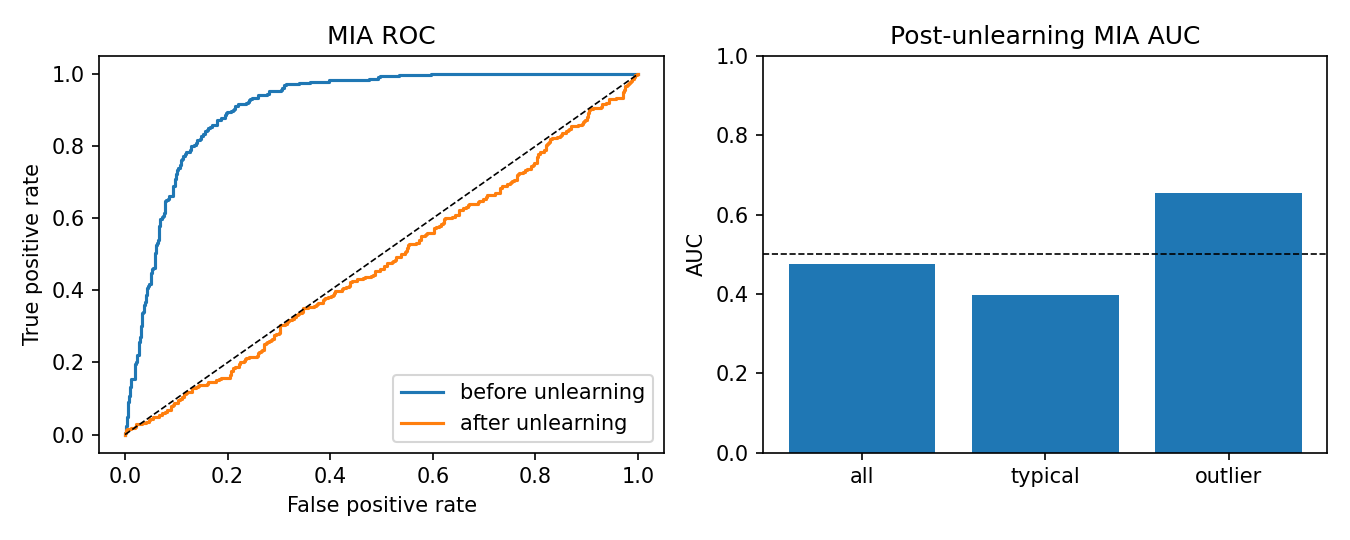

In [7]:
!python -m unlearning.plotting --results results --name tofu_colab_gpt2med
from IPython.display import Image
Image('results/tofu_colab_gpt2med/figure_mia.png')

## 7. Save your results
Download the run folder so you keep metrics + figures after the session ends.


In [8]:
!zip -r tofu_colab_results.zip results/tofu_colab_gpt2med
from google.colab import files
files.download('tofu_colab_results.zip')


  adding: results/tofu_colab_gpt2med/ (stored 0%)
  adding: results/tofu_colab_gpt2med/scores.npz (deflated 20%)
  adding: results/tofu_colab_gpt2med/metrics.json (deflated 60%)
  adding: results/tofu_colab_gpt2med/figure_mia.png (deflated 13%)
  adding: results/tofu_colab_gpt2med/config.resolved.json (deflated 52%)
  adding: results/tofu_colab_gpt2med/figure_mia.pdf (deflated 26%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Notes
- Free Colab disconnects after ~90 min idle (and ~12 h max). Keep the tab active.
- If `nvidia-smi` shows no GPU, re-check the runtime type.
- To try a gated model (e.g. Llama-3.2-1B) add `!huggingface-cli login`, accept the
  model licence on its HF page, and implement LoRA first (full fine-tune of 1B is tight).
